### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

In [19]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df

# divido la soluzione in più pezzi di codice per far vedere ogni punto
# 1.
df.sort_values(by='total_litres_of_pure_alcohol', ascending=False, inplace=True)
df.head(10)


,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
15,Belarus,142,373,42,14.4
98,Lithuania,343,244,56,12.9
3,Andorra,245,138,312,12.4
68,Grenada,199,438,28,11.9
45,Czech Republic,361,170,134,11.8
61,France,127,151,370,11.8
141,Russian Federation,247,326,73,11.5
81,Ireland,313,118,165,11.4
155,Slovakia,196,293,116,11.4
99,Luxembourg,236,133,271,11.4


In [20]:
# 2.
df.groupby("country")[["beer_servings","wine_servings","spirit_servings"]].mean()

,beer_servings,wine_servings,spirit_servings
country,,,
Afghanistan,0.0,0.0,0.0
Albania,89.0,54.0,132.0
Algeria,25.0,14.0,0.0
Andorra,245.0,312.0,138.0
Angola,217.0,45.0,57.0
...,...,...,...
Venezuela,333.0,3.0,100.0
Vietnam,111.0,1.0,2.0
Yemen,6.0,0.0,0.0


In [21]:
# 3.
df["alcohol_index"] = (df.beer_servings + df.wine_servings + df.spirit_servings) / 3
df["alcohol_index"]

15     185.666667
98     214.333333
3      231.666667
68     221.666667
45     221.666667
          ...    
79       0.000000
90       0.000000
128      0.000000
97       0.000000
0        0.000000
Name: alcohol_index, Length: 193, dtype: float64

In [22]:
# 4.
df["alcohol_index"].idxmax() # risulta 3
df.loc[3] # il paese risultante è Andorra

country                            Andorra
beer_servings                          245
spirit_servings                        138
wine_servings                          312
total_litres_of_pure_alcohol          12.4
alcohol_index                   231.666667
Name: 3, dtype: object

In [23]:
# 5.
df[df["beer_servings"] > 100]

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,alcohol_index
15,Belarus,142,373,42,14.4,185.666667
98,Lithuania,343,244,56,12.9,214.333333
3,Andorra,245,138,312,12.4,231.666667
68,Grenada,199,438,28,11.9,221.666667
45,Czech Republic,361,170,134,11.8,221.666667
...,...,...,...,...,...,...
29,Cabo Verde,144,56,16,4.0,72.000000
170,Macedonia,106,27,86,3.9,73.000000
20,Bolivia,167,41,8,3.8,72.000000
146,Samoa,105,18,24,2.6,49.000000


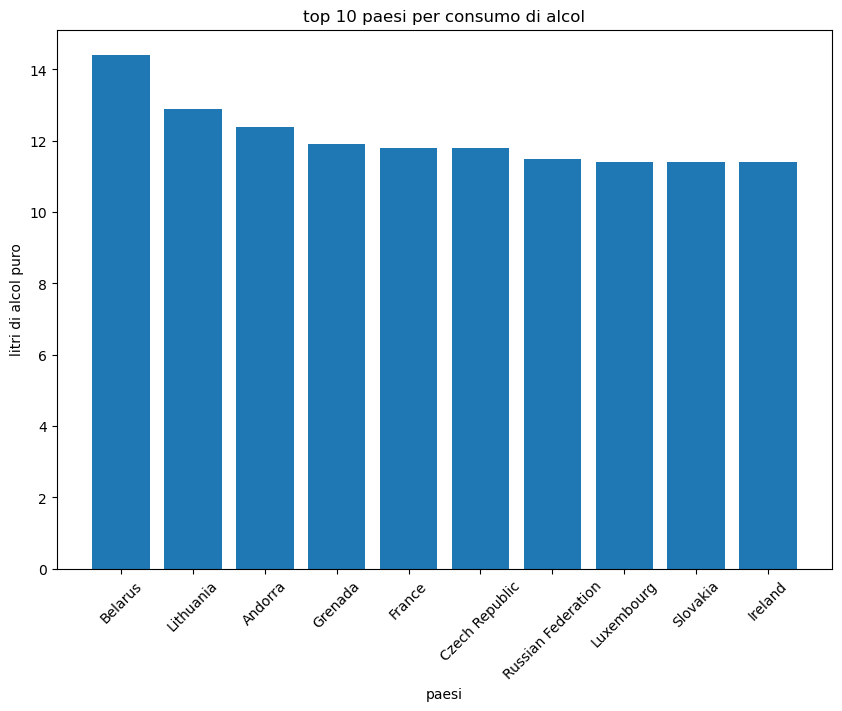

In [27]:
# 6.
import matplotlib.pyplot as plt 

df.sort_values(by="total_litres_of_pure_alcohol", ascending=False, inplace=True)
top10 = df.head(10)

plt.figure(figsize=(10,7))

plt.bar(top10["country"], top10["total_litres_of_pure_alcohol"])


plt.xticks(rotation=45)
plt.title("top 10 paesi per consumo di alcol")
plt.xlabel("paesi")
plt.ylabel("litri di alcol puro")

plt.show()




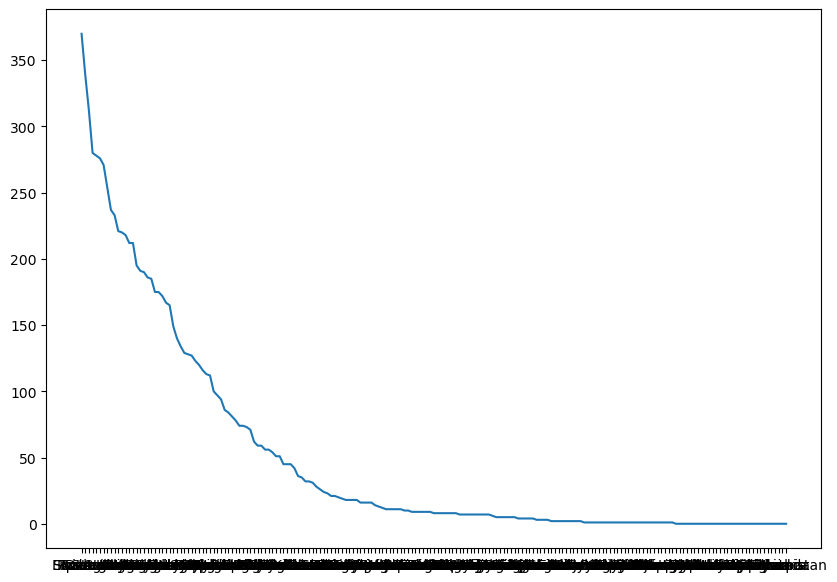

In [28]:
# 7.
df.sort_values(by="wine_servings", ascending=False, inplace=True)

plt.figure(figsize=(10,7))

plt.plot(df.country,df.wine_servings)
# ovviamente però i paesi sono così tanti che nel grafico sono indecifrabili
plt.show()

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

stipendio medio annuale per paese:
 job_country
Afghanistan             NaN
Albania         79472.50000
Algeria         44550.00000
Angola                  NaN
Argentina      105212.34375
Name: salary_year_avg, dtype: float64


numero totale di offerte di lavoro per paese:
 job_country
United States     206292
India              51088
United Kingdom     40375
France             39922
Germany            27694
Name: count, dtype: int64


stipendi minimi e massimi per paese:
                  min       max
job_country                   
Afghanistan      NaN       NaN
Albania      43200.0  157500.0
Algeria      44100.0   45000.0
Angola           NaN       NaN
Argentina    45000.0  222000.0


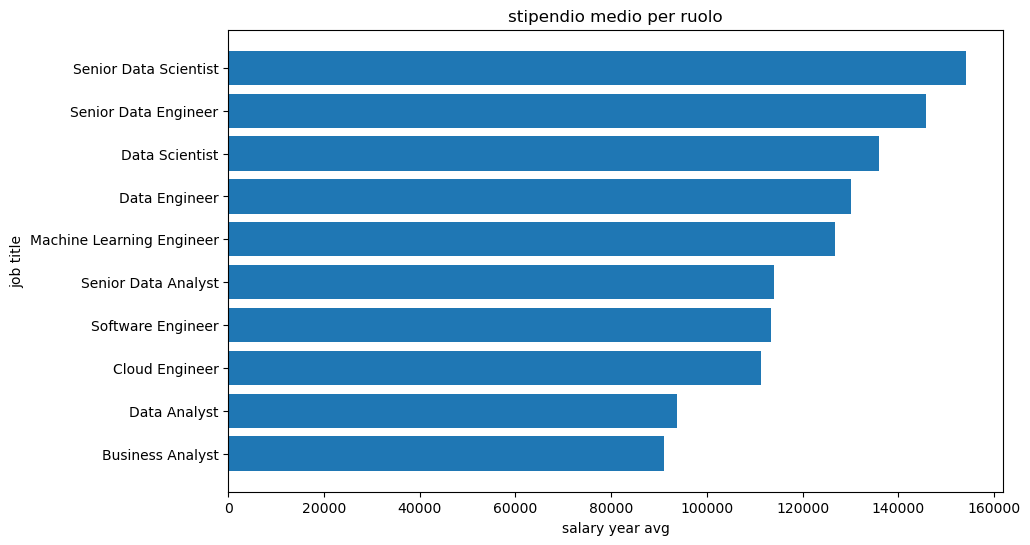

In [2]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# 1.
avg_salary_per_country = df.groupby("job_country")["salary_year_avg"].mean()
print("stipendio medio annuale per paese:\n", avg_salary_per_country.head())
print("\n")

# 2.
job_count_per_country = df["job_country"].value_counts()
print("numero totale di offerte di lavoro per paese:\n", job_count_per_country.head())
print("\n")

# 3.
salary_range = df.groupby("job_country")["salary_year_avg"].agg(["min", "max"])
print("stipendi minimi e massimi per paese:\n", salary_range.head())

# 4. 
avg_by_job = df.groupby("job_title_short")["salary_year_avg"].mean()
avg_by_job = avg_by_job.sort_values(ascending=False)


plt.figure(figsize=(10,6))

plt.barh(avg_by_job.index, avg_by_job.values)

plt.title("stipendio medio per ruolo")
plt.xlabel("salary year avg")
plt.ylabel("job title")

plt.gca().invert_yaxis()  # per avere il più alto in alto

plt.show()

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [30]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [31]:
# 1.
mean_per_day = df.groupby("day")["total_bill"].mean()
mean_per_day

day
Fri     17.151579
Sat     20.441379
Sun     21.410000
Thur    17.682742
Name: total_bill, dtype: float64

In [32]:
# 2.
tot_obs = df["day"].count()
print("numero totale di osservazioni:",tot_obs)

# 3.
min_per_day = df.groupby("day")["total_bill"].min()
print("valori minimi per giorno:\n",min_per_day)
max_per_day = df.groupby("day")["total_bill"].max()
print("valori massimi per giorno:\n",max_per_day)

# 4.
df["conto_per_persona"] = df["total_bill"]/df["size"]
df.head(10)

numero totale di osservazioni: 244
valori minimi per giorno:
 day
Fri     5.75
Sat     3.07
Sun     7.25
Thur    7.51
Name: total_bill, dtype: float64
valori massimi per giorno:
 day
Fri     40.17
Sat     50.81
Sun     48.17
Thur    43.11
Name: total_bill, dtype: float64


,total_bill,tip,sex,smoker,day,time,size,conto_per_persona
0,16.99,1.01,Female,No,Sun,Dinner,2,8.495000
1,10.34,1.66,Male,No,Sun,Dinner,3,3.446667
2,21.01,3.50,Male,No,Sun,Dinner,3,7.003333
3,23.68,3.31,Male,No,Sun,Dinner,2,11.840000
4,24.59,3.61,Female,No,Sun,Dinner,4,6.147500
5,25.29,4.71,Male,No,Sun,Dinner,4,6.322500
6,8.77,2.00,Male,No,Sun,Dinner,2,4.385000
7,26.88,3.12,Male,No,Sun,Dinner,4,6.720000
8,15.04,1.96,Male,No,Sun,Dinner,2,7.520000
9,14.78,3.23,Male,No,Sun,Dinner,2,7.390000


In [33]:
# 5.
day_max = mean_per_day.idxmax()
print("giorno con conto medio massimo:",day_max)

giorno con conto medio massimo: Sun


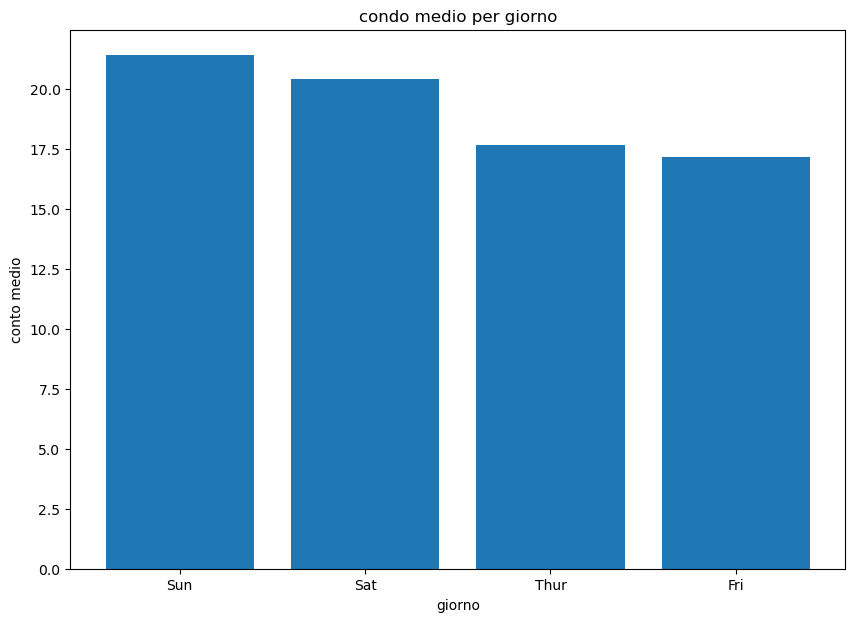

In [34]:
# 6.
mean_per_day = mean_per_day.sort_values(ascending=False)

plt.figure(figsize=(10,7))

plt.bar(mean_per_day.index,mean_per_day.values)
plt.title("condo medio per giorno")
plt.xlabel("giorno")
plt.ylabel("conto medio")

plt.show()
